# GDL - Midterm n.2

In the second midterm assignment, you are required to implement the layers of a **Convolutional Neural Network (CNN)** using **only NumPy**. You will test your implementation using pre-trained parameters, which are provided in a `zip` file that you should extract in the `params/` folder.

You are **not** allowed to use JAX, PyTorch, TensorFlow, or any other ML framework.

**Summary.** Overall, you are required to implement the following functions:
1. **`conv2d`**. 2D convolution
3. **`max_pool`**. Max-pooling.
4. **`avg_pool`**. Average-pooling.
5. **`relu`**. ReLU activation function.
6. **`cnn_forward`**. Implements the CNN architecture described in the provided docstring.

**Evaluation.** You can test your implementation by loading the provided parameters and evaluating on four selected samples. We will check your implementation with further hidden tests.

**Do not alter Sections 1 and 3 of the notebook**, instead **work only in Section 2**.

⚠️ **Fill the following cell with your student ID (matricola) and submission ID** ⚠️

In [146]:
# your student "matricola" goes here
student_id = 583309
# the ID from the sheet circulated in classroom goes here
submission_id = 22

assert student_id is not None and submission_id is not None, (
    "Fill the student_id and submission_id before submitting!"
)

### 1. Libraries and Data Loading

Run these cells to download MNIST and load parameters in the `params` dictionary. You should place all the provided `npy` files in the `params/` directory.

In [147]:
import os
import struct
import gzip
import hashlib
import urllib.request
import numpy as np

In [148]:
# Download MNIST

MNIST_URL = "https://storage.googleapis.com/cvdf-datasets/mnist/"
MNIST_TEST_FILES = {
    "test_images": (
        "t10k-images-idx3-ubyte.gz",
        "8d422c7b0a1c1c79245a5bcf07fe86e33eeafee792b84584aec276f5a2dbc4e6",
    ),
    "test_labels": (
        "t10k-labels-idx1-ubyte.gz",
        "f7ae60f92e00ec6debd23a6088c31dbd2371eca3ffa0defaefb259924204aec6",
    ),
}
DATA_DIR = "mnist_data"


def _download_file(filename: str, expected_sha256: str) -> str:
    os.makedirs(DATA_DIR, exist_ok=True)
    filepath = os.path.join(DATA_DIR, filename)
    if os.path.exists(filepath):
        sha = hashlib.sha256(open(filepath, "rb").read()).hexdigest()
        if sha == expected_sha256:
            return filepath
        print(f"Hash mismatch for {filename}, re-downloading …")

    url = MNIST_URL + filename
    print(f"Downloading {url} …")
    urllib.request.urlretrieve(url, filepath)

    sha = hashlib.sha256(open(filepath, "rb").read()).hexdigest()
    if sha != expected_sha256:
        raise RuntimeError(
            f"SHA-256 mismatch for {filename}: expected {expected_sha256}, got {sha}"
        )
    return filepath


def _parse_images(filepath: str) -> np.ndarray:
    """Parse IDX image file -> (N, 1, 28, 28) float32 in [0, 1]."""
    with gzip.open(filepath, "rb") as f:
        _, num, rows, cols = struct.unpack(">IIII", f.read(16))
        data = np.frombuffer(f.read(), dtype=np.uint8)
    return data.reshape(num, 1, rows, cols).astype(np.float32) / 255.0


def _parse_labels(filepath: str) -> np.ndarray:
    """Parse IDX label file -> (N,) int32."""
    with gzip.open(filepath, "rb") as f:
        _, num = struct.unpack(">II", f.read(8))
        data = np.frombuffer(f.read(), dtype=np.uint8)
    return data.astype(np.int32)


def load_mnist_test():
    """Return (test_images, test_labels)."""
    paths = {k: _download_file(*v) for k, v in MNIST_TEST_FILES.items()}
    return _parse_images(paths["test_images"]), _parse_labels(paths["test_labels"])


test_images, test_labels = load_mnist_test()
print(f"\nTest set: {test_images.shape[0]} images, shape={test_images.shape}")


Test set: 10000 images, shape=(10000, 1, 28, 28)


In [149]:
# Load parameters

PARAM_NAMES = [
    "conv1_weight",
    "conv1_bias",
    "conv2_weight",
    "conv2_bias",
    "fc1_weight",
    "fc1_bias",
    "fc2_weight",
    "fc2_bias",
]
PARAMS_DIR = "params"


def load_params(params_dir: str) -> dict:
    """Load all .npy parameter files from params_dir into a dict."""
    params = {}
    print("Parameter\tShape")
    for name in PARAM_NAMES:
        filepath = os.path.join(params_dir, f"{name}.npy")
        if not os.path.exists(filepath):
            raise FileNotFoundError(
                f"Parameter file not found: {filepath}\n"
                "Make sure the params/ folder is in the working directory."
            )
        params[name] = np.load(filepath).astype(np.float32)
        print(f"{name}\t{params[name].shape}")
    return params


params = load_params(PARAMS_DIR)

Parameter	Shape
conv1_weight	(32, 1, 3, 3)
conv1_bias	(32,)
conv2_weight	(64, 32, 3, 3)
conv2_bias	(64,)
fc1_weight	(128, 1024)
fc1_bias	(128,)
fc2_weight	(10, 128)
fc2_bias	(10,)


### 2. CNN Implementation

Implement the five functions below using numpy only **WITHOUT USING `np.convolve`**. The implementation should highlight your understanding of the inner workings of a Convolutional Network, try to be expressive and avoid shortcuts!

The functions `conv2d`, `max_pool` and `avg_pool` must input and output batches in the `NCHW` format, where:
1. `N` is the number of samples,
2. `C` is the number of channels,
3. `H` is the height, and
4. `W` is the width.

In [150]:
def convolve(x: np.ndarray, w: np.ndarray, b: float, stride: int) -> np.ndarray:
    """
    Convolution of one sample with one kernel and the given stride
    """

    # compute output size
    H_out = (x.shape[1] - w.shape[1]) // stride + 1
    W_out = (x.shape[2] - w.shape[2]) // stride + 1

    # get kernel height and width
    H = w.shape[1]
    W = w.shape[2]

    output = np.zeros(shape=(H_out, W_out))
    for i in range(H_out):
        for j in range(W_out):
            output[i][j] = (
                np.sum(
                    x[
                        :,
                        i * stride : i * stride + H,
                        j * stride : j * stride + W,
                    ]
                    * w
                )
                + b
            )

    return output


def conv2d(
    x: np.ndarray, w: np.ndarray, b: np.ndarray, stride: int, padding: int
) -> np.ndarray:
    """
    Bidimensional convolution from C_in input channels to C_out output channels.
    The convolution has kernel size (kH x kW) and arbitrary stride and padding.

    Shapes:
      - W: (C_out, C_in, kH, kW)
      - b: (C_out,)
    """

    N = x.shape[0]

    # padding
    padded_x = []
    for i in range(N):
        padded_x.append(
            np.pad(x[i], pad_width=((0, 0), (padding, padding), (padding, padding)))
        )
    x = np.array(padded_x)

    # compute output size
    H_out = (x.shape[2] - w.shape[2]) // stride + 1
    W_out = (x.shape[3] - w.shape[3]) // stride + 1

    C_out = w.shape[0]
    output = np.zeros(shape=(N, C_out, H_out, W_out))
    for i in range(N):  # iterate of samples
        for j in range(C_out):  # iterate over kernels
            # convolve one sample with one kernel
            output[i][j] = convolve(x[i], w[j], b[j], stride)

    return output

In [151]:
def max_pool_sample(x: np.ndarray, pool_size: int, stride: int) -> np.ndarray:

    # compute output size
    H, W = x.shape
    H_out = (H - pool_size) // stride + 1
    W_out = (W - pool_size) // stride + 1

    output = np.zeros(shape=(H_out, W_out))
    for i in range(H_out):
        for j in range(W_out):
            output[i][j] = np.max(
                x[
                    i * stride : i * stride + pool_size,
                    j * stride : j * stride + pool_size,
                ]
            )

    return output


def max_pool(x: np.ndarray, pool_size: int = 2, stride: int = 2) -> np.ndarray:
    """
    Max-pooling with arbitrary pool size and stride.
    """

    N, C, H, W = x.shape
    H_out = (H - pool_size) // stride + 1
    W_out = (W - pool_size) // stride + 1

    output = np.zeros(shape=(N, C, H_out, W_out))
    for i in range(N):
        for j in range(C):
            output[i][j] = max_pool_sample(x[i][j], pool_size, stride)

    return output

In [152]:
def avg_pool_sample(x: np.ndarray, pool_size: int, stride: int) -> np.ndarray:

    # compute output size
    H, W = x.shape
    H_out = (H - pool_size) // stride + 1
    W_out = (W - pool_size) // stride + 1

    output = np.zeros(shape=(H_out, W_out))
    for i in range(H_out):
        for j in range(W_out):
            output[i][j] = np.average(
                x[
                    i * stride : i * stride + pool_size,
                    j * stride : j * stride + pool_size,
                ]
            )

    return output


def avg_pool(x: np.ndarray, pool_size: int = 2, stride: int = 2) -> np.ndarray:
    """
    Average-pooling with arbitrary pool size and stride.
    """

    N, C, H, W = x.shape
    H_out = (H - pool_size) // stride + 1
    W_out = (W - pool_size) // stride + 1

    output = np.zeros(shape=(N, C, H_out, W_out))
    for i in range(N):
        for j in range(C):
            output[i][j] = avg_pool_sample(x[i][j], pool_size, stride)

    return output

In [153]:
def relu(x: np.ndarray) -> np.ndarray:
    """
    Rectified Linear Unit activation.
    """
    return np.maximum(0, x)


In [ ]:
def cnn_forward(params: dict, x: np.ndarray) -> np.ndarray:
    """
    Forward pass of the CNN using pure NumPy.
    The architecture is:
        Conv1 (1->32, 3x3 kernel, stride=2, padding=1) -> ReLU -> AvgPool(2x2, stride=2)
        Conv2 (32->64, 3x3 kernel, stride=1, padding=2) -> ReLU -> MaxPool(2x2, stride=2)
        Flatten
        FC1 (1024->128) -> ReLU
        FC2 (128->10)
    """
    # conv1
    out = conv2d(x, params["conv1_weight"], params["conv1_bias"], 2, 1)
    out = relu(out)
    out = avg_pool(out, 2, 2)

    # conv2
    out = conv2d(out, params["conv2_weight"], params["conv2_bias"], 1, 2)
    out = relu(out)
    out = max_pool(out, 2, 2)

    # flatten
    out = out.reshape(out.shape[0], -1)

    # fc1
    out = out @ params["fc1_weight"].T + params["fc1_bias"]
    out = relu(out)

    # fc2
    out = out @ params["fc2_weight"].T + params["fc2_bias"]

    return out

### 3. Evaluation

This section evaluates your implementation on the MNIST test set using the pre-trained parameters. On the following images, a correct implementation correctly classifies the first two images and misclassifies the second two.

**Do not alter this section.**

In [155]:
indices = np.array([0, 1, 78, 320])
sample_images = test_images[indices]
sample_labels = test_labels[indices]

# Perform forward pass
logits = cnn_forward(params, sample_images)
predictions = np.argmax(logits, axis=-1)

for i in range(4):
    print(f"Index {i} | GT={sample_labels[i]} | cnn(x)={predictions[i]}")

(4, 10)
Index 0 | GT=7 | cnn(x)=7
Index 1 | GT=2 | cnn(x)=2
Index 2 | GT=9 | cnn(x)=8
Index 3 | GT=9 | cnn(x)=8


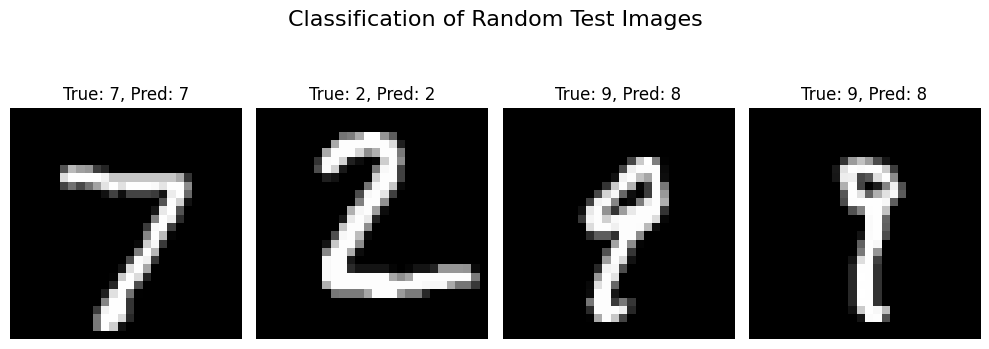

In [156]:
import matplotlib.pyplot as plt

# Display the images and their classifications
plt.figure(figsize=(10, 4))
for i in range(4):
    plt.subplot(1, 4, i + 1)
    plt.imshow(sample_images[i].reshape(28, 28), cmap="gray")
    plt.title(f"True: {sample_labels[i]}, Pred: {predictions[i]}")
    plt.axis("off")
plt.suptitle("Classification of Random Test Images", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()